In [36]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import pickle
import time
from copy import deepcopy

import torch  # imported first on purpose: on Windows it must win the DLL search over matplotlib/sklearn

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tabulate import tabulate

from datasets.cardio import infer_node_types, load_cardio_dataframe
from utils.cardio import (
    derive_kaam_mixed_variants,
    evaluate_cardio_observational,
    fit_cardio_model,
    sweep_beta_weight,
)
from utils.paths import get_experiment_paths

print(f'python : {sys.executable}')
print(f'torch  : {torch.__version__}')

python : c:\Users\aarna\miniconda3\envs\TFM_clau\python.exe
torch  : 2.13.0+cpu


In [37]:
# Load the dataset
data_cardio = load_cardio_dataframe()

# TEMPORAL: SMOKE TEST N=20 -- delete the next two lines to go back to the full dataset
SMOKE_TEST_N = 20
data_cardio = data_cardio.sample(n=SMOKE_TEST_N, random_state=42).reset_index(drop=True)

print(data_cardio.head())
print(f'Number of patients: {len(data_cardio)}')


   ischemia  macv  age  systolic   bmi  diabetes
0         0     0   54       160  29.4         0
1         0     0   48       149  30.9         0
2         0     0   65       158  27.3         0
3         0     0   53       115  26.0         0
4         1     1   55       138  24.3         0
Number of patients: 20


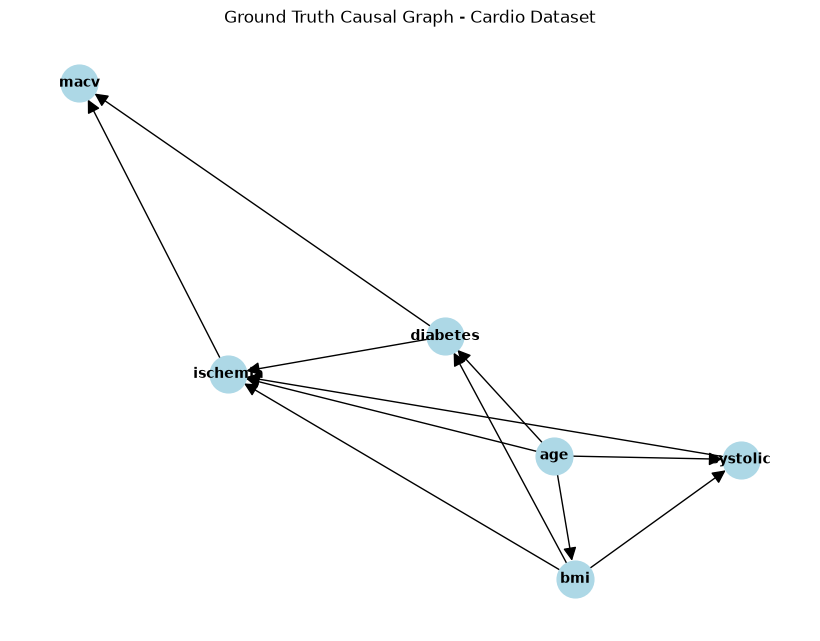

In [38]:
# Graph defined by our reference paper
graph_cardio = nx.DiGraph([('age', 'diabetes'), ('age', 'systolic'), ('age', 'ischemia'), ('age', 'bmi'),
                            ('bmi', 'systolic'), ('bmi', 'ischemia'), ('bmi', 'diabetes'),
                            ('systolic', 'ischemia'),
                            ('diabetes', 'macv'), ('diabetes', 'ischemia'),
                            ('ischemia', 'macv')])

# Show the ground truth graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(graph_cardio)
nx.draw(graph_cardio, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
plt.title("Ground Truth Causal Graph - Cardio Dataset")
plt.show()

Train set shape: (10, 6), Test set shape: (10, 6)


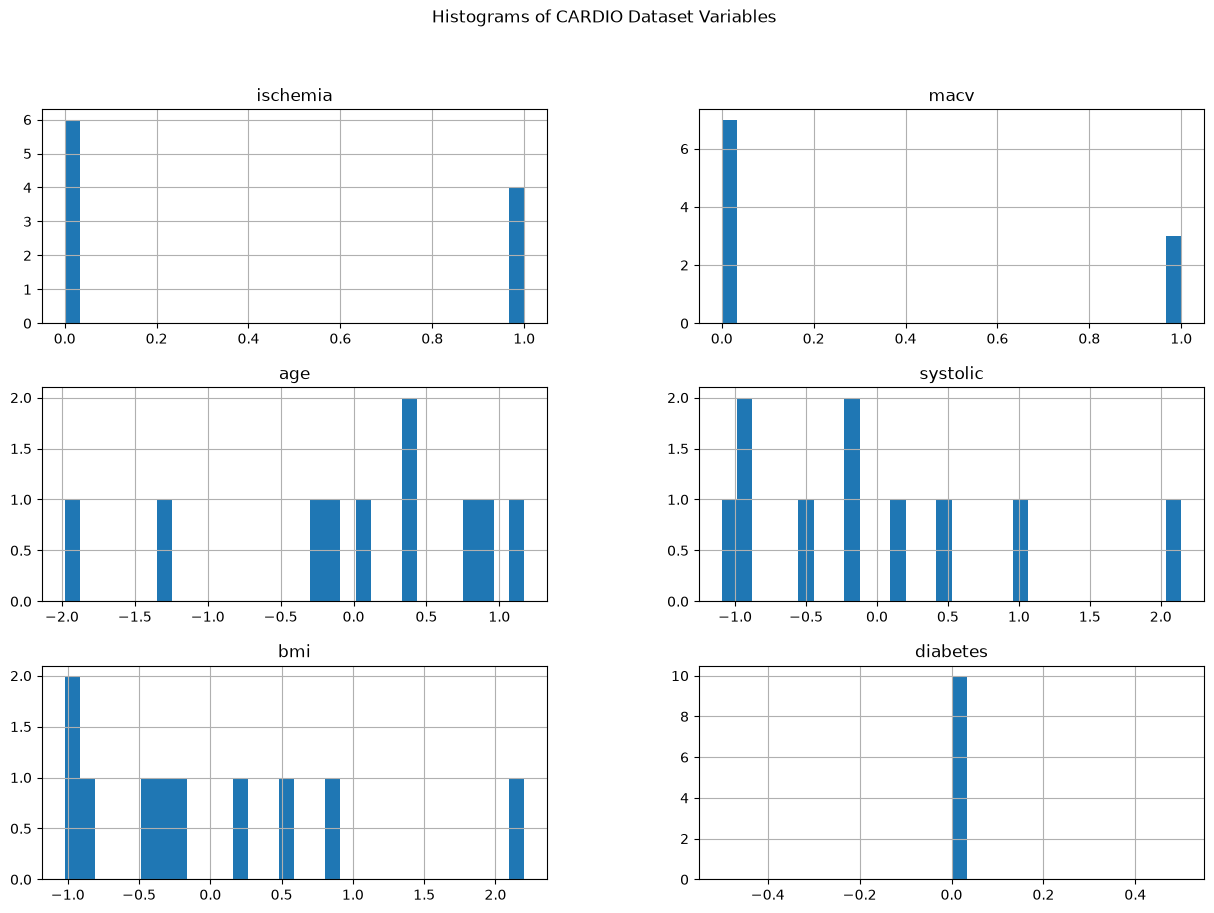

In [39]:
# Prepare the values for the later analysis
split_eval = 0.5  # Use half of the samples for training and half for evaluation
np.random.seed(42)  # Set seed for repeatability

factual_train_d, factual_eval_d = train_test_split(data_cardio, test_size=split_eval, random_state=42)
nodes = factual_train_d.columns

# Some nodes are continuous and some are discrete: preprocess accordingly
int_min_val = -3
int_max_val = 3
int_step = 0.1
int_vector_values = np.arange(int_min_val, int_max_val, int_step)  # This is for continuous nodes

node_info = {}
for node in nodes:
    node_info[node] = {}
    # First, assess if the node is continuous or discrete
    if len(factual_train_d[node].unique()) > 5:
        node_info[node]['type'] = 'continuous'
        node_info[node]['mean'] = factual_train_d[node].mean()
        node_info[node]['std'] = factual_train_d[node].std()
        factual_train_d[node] = (factual_train_d[node] - node_info[node]['mean']) / node_info[node]['std']
        factual_eval_d[node] = (factual_eval_d[node] - node_info[node]['mean']) / node_info[node]['std']
        node_info[node]['int_values'] = tuple(int_vector_values)
        node_info[node]['percentile_25'] = np.percentile(factual_eval_d[node], 25)
        node_info[node]['percentile_75'] = np.percentile(factual_eval_d[node], 75)
        node_info[node]['percentile_50'] = np.median(factual_eval_d[node])
    else:
        node_info[node]['type'] = 'discrete'
        node_info[node]['int_values'] = (0, 1) # In this dataset, all discrete variables are binary

def post_process_samples(df, denorm=False):
    for node in df.columns:
        if node_info[node]['type'] == 'discrete':
            df[node] = df[node].astype(int)
            df[node] = np.clip(df[node], min(node_info[node]['int_values']), max(node_info[node]['int_values']))
    if denorm:
        for node in df.columns:
            if node_info[node]['type'] == 'continuous':
                df[node] = df[node] * node_info[node]['std'] + node_info[node]['mean']
    return df

print(f'Train set shape: {factual_train_d.shape}, Test set shape: {factual_eval_d.shape}')

paths = get_experiment_paths('cardio')
results_bdir = str(paths.root)
images_dir = str(paths.images)
samples_dir = str(paths.samples)
data_dir = str(paths.data)

factual_train_d.to_csv(os.path.join(data_dir, 'cardio_factual_train_d.csv'), index=False)
factual_eval_d.to_csv(os.path.join(data_dir, 'cardio_factual_eval_d.csv'), index=False)

# Stored so cardio_hsic_results.ipynb can denormalise its axes without re-deriving the split
with open(os.path.join(data_dir, 'cardio_node_info.pkl'), 'wb') as f:
    pickle.dump(node_info, f, protocol=pickle.HIGHEST_PROTOCOL)

# Create a continuous version of the data by adding small noise to the discrete values (used for training in continuous models)
factual_train_dn = factual_train_d + np.random.normal(0, 0.01, factual_train_d.shape)
factual_train_dn.to_csv(os.path.join(samples_dir, f"cardio_factual_train_dn.csv"), index=False)

# Show a histogram of all the variables in the dataset, both of train and test
factual_train_d.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histograms of CARDIO Dataset Variables")
plt.show()

In [40]:
# Configuration for the training runs.
# The 'kan', 'kaam' and 'anm' baselines are intentionally excluded: this notebook only
# covers the mixed KAN family plus the DBCM and causal-flow baselines. KAAM is trained
# first so cardio_hsic_results.ipynb can analyse the symbolic mechanisms as early as possible.
MODEL_NAMES = ['kaam_mixed', 'kan_mixed', 'dbcm', 'flow']

# Hybrid loss weight for the KAN family, with alpha = 1 - beta (Experimento1 convention):
#   loss = alpha * MSE/Var(Y) + beta * nHSIC(parents, residual)
# Start from 0.1 to exclude beta=0 from optimization; beta=0 will be trained separately as a reference.
BETA_VALUES = [round(float(b), 2) for b in np.arange(0.1, 0.9, 0.1)]  # 0.1 ... 0.8

verbose = True
n_threads = 9

node_types, num_classes = infer_node_types(factual_train_d, default_num_classes=2)

models = {}
results = {}
best_params = {}
arch_params = {}
beta_sweeps = {}

root_nodes = [n for n in graph_cardio.nodes if graph_cardio.in_degree(n) == 0]
beta_nodes = [n for n in graph_cardio.nodes if graph_cardio.in_degree(n) > 0 and node_types[n] == 'continuous']

print(f'Models        : {MODEL_NAMES}')
print(f'Beta values   : {BETA_VALUES}')
print(f'Node types    : {node_types}')
print(f'Root nodes    : {root_nodes}  (fitted as a normal distribution, no KAN and no beta)')
print(f'Beta searched : {beta_nodes}  (continuous non-root nodes only)')
print(f'Cross-entropy : {[n for n in graph_cardio.nodes if graph_cardio.in_degree(n) > 0 and node_types[n] == "discrete"]}  (no residual, so beta is inert)')

Models        : ['kaam_mixed', 'kan_mixed', 'dbcm', 'flow']
Beta values   : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
Node types    : {'ischemia': 'discrete', 'macv': 'discrete', 'age': 'continuous', 'systolic': 'continuous', 'bmi': 'continuous', 'diabetes': 'discrete'}
Root nodes    : ['age']  (fitted as a normal distribution, no KAN and no beta)
Beta searched : ['systolic', 'bmi']  (continuous non-root nodes only)
Cross-entropy : ['diabetes', 'ischemia', 'macv']  (no residual, so beta is inert)


In [41]:
# Shared evaluate-and-persist step, so each model cell below stays a single training call.
# Writes exactly the artefacts the previous flow produced, one set per model name.
def evaluate_and_store(name, model, sample_seed=42, model_type=None):
    # model_type drives dispatch inside evaluate_cardio_observational (residuals/formulas logic
    # matches on the canonical name, e.g. 'kaam_mixed_symbolic'); name drives file naming, so
    # variants like the beta=0 reference models can share dispatch but write to their own files.
    model_type = model_type or name
    metrics, obs_samples, residuals, extras = evaluate_cardio_observational(
        model_type, model, factual_eval_d, node_info, sample_seed=sample_seed
    )
    results.setdefault(name, {'model': name})
    results[name].update(metrics)

    obs_samples.to_csv(os.path.join(samples_dir, f'cardio_obs_samples_{name}.csv'), index=False)
    with open(os.path.join(samples_dir, f'cardio_obs_samples_{name}.pkl'), 'wb') as f:
        pickle.dump(obs_samples, f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(os.path.join(samples_dir, f'cardio_residuals_{name}.pkl'), 'wb') as f:
        pickle.dump(residuals, f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(os.path.join(data_dir, f'cardio_results_{name}.pkl'), 'wb') as f:
        pickle.dump(results[name], f, protocol=pickle.HIGHEST_PROTOCOL)

    # Only kaam_mixed_symbolic carries formulas; this file feeds the results notebook.
    # Beta=0 variants write to a separate file so they don't clobber the optimal-beta formulas.
    if extras.get('formulas'):
        formulas_name = 'cardio_formulas_kaam_beta0.pkl' if name.endswith('_beta0') else 'cardio_formulas_kaam.pkl'
        with open(os.path.join(samples_dir, formulas_name), 'wb') as f:
            pickle.dump(extras['formulas'], f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f'  formulas -> {formulas_name}')
        for node, formula in extras['formulas'].items():
            print(f'    {node} = {formula}')

    shown = {k: round(float(v), 4) for k, v in metrics.items()}
    print(f"  {name}: {shown}")
    return metrics


def report_selected_beta(name):
    """Print the beta chosen per node, for the models where it was searched."""
    if name not in best_params:
        return
    chosen = {node: p.get('beta_weight') for node, p in best_params[name].items()}
    searched = {node: b for node, b in chosen.items() if node in beta_nodes}
    print(f"  selected beta (searched nodes): {searched}")

In [42]:
# STAGE 1 is no longer searched here: the architecture per node is the one already selected by
# the reference cardio grid search (243 combinations, criterion rf_acc[node] + rf_acc['all']),
# transcribed from notebooks/alejandro/cardio.ipynb. Only beta is searched, in stage 2 below.
KAN_SHARED_PARAMS = dict(batch_size=-1, seed=0, early_stop=True, steps=10000,
                         lamb_entropy=0.1, sparse_init=False, try_gpu=False, loss='mse')

# Only these six keys varied across the grid; everything else is the shared block above.
SELECTED_ARCH_PARAMS = {
    'kan_mixed': {
        'diabetes': dict(hidden_dim=5, grid=5, k=10, lr=0.0001, lamb=0.001, mult_kan=False),
        'systolic': dict(hidden_dim=5, grid=10, k=10, lr=0.001, lamb=0.001, mult_kan=True),
        'ischemia': dict(hidden_dim=5, grid=10, k=10, lr=0.001, lamb=0.001, mult_kan=True),
        'bmi': dict(hidden_dim=0, grid=1, k=10, lr=0.001, lamb=0.1, mult_kan=False),
        'macv': dict(hidden_dim=0, grid=10, k=10, lr=0.0001, lamb=0.001, mult_kan=False),
    },
    # KAAM stays on hidden_dim=0 / mult_kan=False so its activations remain symbolically extractable.
    'kaam_mixed': {
        'diabetes': dict(hidden_dim=0, grid=10, k=10, lr=0.0001, lamb=0.001, mult_kan=False),
        'systolic': dict(hidden_dim=0, grid=10, k=10, lr=0.0001, lamb=0.001, mult_kan=False),
        'ischemia': dict(hidden_dim=0, grid=1, k=1, lr=0.001, lamb=0.001, mult_kan=False),
        'bmi': dict(hidden_dim=0, grid=1, k=10, lr=0.001, lamb=0.1, mult_kan=False),
        'macv': dict(hidden_dim=0, grid=10, k=10, lr=0.0001, lamb=0.001, mult_kan=False),
    },
}

# The baselines have no beta stage, so these are the final parameters used at fit time.
SELECTED_DBCM_PARAMS = dict(num_epochs=500, lr=0.01, batch_size=32, hidden_dim=128)
SELECTED_FLOW_PARAMS = dict(flow_type='CausalNSF', hidden_dims=(32, 32), base_lr=0.01,
                            early_stopping_patience=30, scheduler=None, batch_size=256,
                            train_val_split=(0.8, 0.2), max_epochs=1000, device='cpu', bins=8)

non_root_nodes = {n for n in graph_cardio.nodes if graph_cardio.in_degree(n) > 0}
for name in ['kan_mixed', 'kaam_mixed']:
    missing = non_root_nodes - set(SELECTED_ARCH_PARAMS[name])
    assert not missing, f'{name}: no selected architecture for {sorted(missing)}'
    # node_types / num_classes come from THIS split, not from the reference run.
    arch_params[name] = {
        node: {**KAN_SHARED_PARAMS, **varied, 'node_types': node_types, 'num_classes': num_classes}
        for node, varied in SELECTED_ARCH_PARAMS[name].items()
    }

print('Stage 1 skipped: using the pre-selected architecture (no grid search).')
for name, params in arch_params.items():
    print(f'\n{name}')
    for node, p in params.items():
        print(f"  {node:9s} hidden_dim={p['hidden_dim']}  grid={p['grid']}  k={p['k']}  "
              f"lr={p['lr']}  lamb={p['lamb']}  mult_kan={p['mult_kan']}")

Stage 1 skipped: using the pre-selected architecture (no grid search).

kan_mixed
  diabetes  hidden_dim=5  grid=5  k=10  lr=0.0001  lamb=0.001  mult_kan=False
  systolic  hidden_dim=5  grid=10  k=10  lr=0.001  lamb=0.001  mult_kan=True
  ischemia  hidden_dim=5  grid=10  k=10  lr=0.001  lamb=0.001  mult_kan=True
  bmi       hidden_dim=0  grid=1  k=10  lr=0.001  lamb=0.1  mult_kan=False
  macv      hidden_dim=0  grid=10  k=10  lr=0.0001  lamb=0.001  mult_kan=False

kaam_mixed
  diabetes  hidden_dim=0  grid=10  k=10  lr=0.0001  lamb=0.001  mult_kan=False
  systolic  hidden_dim=0  grid=10  k=10  lr=0.0001  lamb=0.001  mult_kan=False
  ischemia  hidden_dim=0  grid=1  k=1  lr=0.001  lamb=0.001  mult_kan=False
  bmi       hidden_dim=0  grid=1  k=10  lr=0.001  lamb=0.1  mult_kan=False
  macv      hidden_dim=0  grid=10  k=10  lr=0.0001  lamb=0.001  mult_kan=False


In [43]:
# STAGE 2: sweep the hybrid weight beta over the stage-1 architecture, one whole-model fit
# per beta. Selection uses the SAME criterion as stage 1 and as the DBCM/flow searches:
# minimise RF accuracy, specifically rf_acc[node] + rf_acc['all'].
#
# Beta is only selected for continuous non-root nodes. kan_model_mixed trains discrete nodes
# with cross-entropy, so they have no additive-noise residual for the HSIC term to act on and
# their fit is identical at every beta.
t0 = time.time()

for name in ['kaam_mixed', 'kan_mixed']:
    best_params[name], sweep = sweep_beta_weight(
        name, arch_params[name], BETA_VALUES, graph_cardio,
        factual_train_d, factual_eval_d, num_classes,
        node_types=node_types, n_jobs=n_threads, verbose=verbose,
    )
    beta_sweeps[name] = sweep
    sweep.to_csv(os.path.join(data_dir, f'cardio_beta_sweep_{name}.csv'), index=False)
    with open(os.path.join(data_dir, f'best_beta_{name}_cardio.pkl'), 'wb') as f:
        pickle.dump({node: p['beta_weight'] for node, p in best_params[name].items()}, f,
                    protocol=pickle.HIGHEST_PROTOCOL)

print(f'\nStage 2 finished in {time.time() - t0:.1f}s')

for name, sweep in beta_sweeps.items():
    searched = sweep[sweep['searched']]
    print(f'\n=== {name}: criterion rf_acc[node] + rf_acc["all"] (lower is better) ===')
    print(searched.pivot_table(index='beta', columns='node', values='criterion').round(4).to_string())
    chosen = {row['node']: row['beta'] for _, row in searched[searched['selected']].iterrows()}
    print(f'selected beta: {chosen}')

Sweeping beta for kaam_mixed on cardio over 8 values: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]


[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   2 out of   8 | elapsed:  1.6min remaining:  4.7min
[Parallel(n_jobs=9)]: Done   3 out of   8 | elapsed:  1.6min remaining:  2.6min
[Parallel(n_jobs=9)]: Done   4 out of   8 | elapsed:  1.6min remaining:  1.6min
[Parallel(n_jobs=9)]: Done   5 out of   8 | elapsed:  1.6min remaining:   57.0s
[Parallel(n_jobs=9)]: Done   6 out of   8 | elapsed:  1.6min remaining:   31.6s
[Parallel(n_jobs=9)]: Done   8 out of   8 | elapsed:  1.7min finished
[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.


Best beta for kaam_mixed: {'diabetes': 0.0, 'systolic': 0.8, 'ischemia': 0.0, 'bmi': 0.1, 'macv': 0.0}
Sweeping beta for kan_mixed on cardio over 8 values: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]


[Parallel(n_jobs=9)]: Done   2 out of   8 | elapsed:  2.4min remaining:  7.1min
[Parallel(n_jobs=9)]: Done   3 out of   8 | elapsed:  2.4min remaining:  3.9min
[Parallel(n_jobs=9)]: Done   4 out of   8 | elapsed:  2.4min remaining:  2.4min
[Parallel(n_jobs=9)]: Done   5 out of   8 | elapsed:  2.4min remaining:  1.4min
[Parallel(n_jobs=9)]: Done   6 out of   8 | elapsed:  2.4min remaining:   47.3s


Best beta for kan_mixed: {'diabetes': 0.0, 'systolic': 0.1, 'ischemia': 0.0, 'bmi': 0.1, 'macv': 0.0}

Stage 2 finished in 247.6s

=== kaam_mixed: criterion rf_acc[node] + rf_acc["all"] (lower is better) ===
node   bmi  systolic
beta                
0.1   1.75      1.75
0.2   1.75      1.75
0.3   1.75      1.75
0.4   1.75      1.75
0.5   1.75      1.75
0.6   1.75      1.75
0.7   1.75      1.75
0.8   1.75      1.50
selected beta: {'bmi': 0.1, 'systolic': 0.8}

=== kan_mixed: criterion rf_acc[node] + rf_acc["all"] (lower is better) ===
node   bmi  systolic
beta                
0.1   1.75      1.75
0.2   1.75      1.75
0.3   1.75      1.75
0.4   1.75      1.75
0.5   1.75      1.75
0.6   1.75      1.75
0.7   1.75      1.75
0.8   1.75      1.75
selected beta: {'bmi': 0.1, 'systolic': 0.1}


[Parallel(n_jobs=9)]: Done   8 out of   8 | elapsed:  2.5min finished


In [44]:
# ---------------------------------------------------------------- KAAM mixed (trained first)
# Also derives the pruned and symbolic variants: to_symbolic is what produces
# cardio_formulas_kaam.pkl, the input to the ischemia analysis in the results notebook.
name = 'kaam_mixed'
report_selected_beta(name)

model, training_time, _ = fit_cardio_model(
    name, graph_cardio, best_params[name], factual_train_d, factual_train_dn, seed=42
)
models[name] = model
results[name] = {'model': name, 'training_time': training_time}
print(f'{name} trained in {training_time:.1f}s')

variants = derive_kaam_mixed_variants(model, factual_train_d, seed=42)
for variant_name, (variant_model, variant_time) in variants.items():
    models[variant_name] = variant_model
    results[variant_name] = {'model': variant_name, 'training_time': variant_time}
    print(f'{variant_name} derived in {variant_time:.1f}s')

for variant_name in [name, 'kaam_mixed_pruned', 'kaam_mixed_symbolic']:
    evaluate_and_store(variant_name, models[variant_name])

  selected beta (searched nodes): {'systolic': 0.8, 'bmi': 0.1}
Using device: cpu
Using device: cpu
Early stopping at step 1360
Using device: cpu
Early stopping at step 67
Using device: cpu
Early stopping at step 31
Using device: cpu
kaam_mixed trained in 84.6s
Found polynomial of degree 2 for input 1/2 and output 1/2 with r2 0.9920. Total time: 0.01s, Iteration time: 0.01s, Average time per output: 0.01s
Found polynomial of degree 2 for input 2/2 and output 1/2 with r2 0.9994. Total time: 0.01s, Iteration time: 0.00s, Average time per output: 0.00s
Symbolic regression results:
Target diabetes:
  Train MAE: 4.8612 (Original: 2.4535), Train R2: 0.0000 (Original: 0.0000)
  Test MAE: 4.4991 (Original: 2.0907), Test R2: 0.0000 (Original: 0.0000)
Found polynomial of degree 3 for input 1/2 and output 1/1 with r2 0.9703. Total time: 0.01s, Iteration time: 0.01s, Average time per output: 0.01s
Found polynomial of degree 1 for input 2/2 and output 1/1 with r2 0.9775. Total time: 0.01s, Iteratio

In [45]:
# ------------------------------------------------------------------------------- KAN mixed
name = 'kan_mixed'
report_selected_beta(name)

model, training_time, _ = fit_cardio_model(
    name, graph_cardio, best_params[name], factual_train_d, factual_train_dn, seed=42
)
models[name] = model
results[name] = {'model': name, 'training_time': training_time}
print(f'{name} trained in {training_time:.1f}s')

evaluate_and_store(name, model)

  selected beta (searched nodes): {'systolic': 0.1, 'bmi': 0.1}
Using device: cpu
Using device: cpu
Early stopping at step 31
Using device: cpu
Early stopping at step 31
Using device: cpu
Early stopping at step 31
Using device: cpu
kan_mixed trained in 124.2s
  kan_mixed: {'mmd_obs_avg': 0.2784, 'rf_acc_obs_avg': 1.0, 'mae': 0.3792, 'hsic': 0.4789, 'dhsic': 0.0131}


{'mmd_obs_avg': 0.2783888209459967,
 'rf_acc_obs_avg': 1.0,
 'mae': 0.37915023917393775,
 'hsic': 0.4789056181907654,
 'dhsic': 0.0131128395727318}

In [46]:
# ------------------------------------------------------------------------------------ DBCM
# Baseline: no beta to search, so it trains straight from the pre-selected parameters.
name = 'dbcm'
best_params[name] = deepcopy(SELECTED_DBCM_PARAMS)
print(f'{name} params: {best_params[name]}')

model, training_time, _ = fit_cardio_model(
    name, graph_cardio, best_params[name], factual_train_d, factual_train_dn, seed=42
)
models[name] = model
results[name] = {'model': name, 'training_time': training_time}
print(f'{name} trained in {training_time:.1f}s')

evaluate_and_store(name, model)

dbcm params: {'num_epochs': 500, 'lr': 0.01, 'batch_size': 32, 'hidden_dim': 128}


Fitting causal mechanism of node macv: 100%|██████████| 6/6 [00:03<00:00,  1.86it/s]    


dbcm trained in 3.2s
  dbcm: {'mmd_obs_avg': 0.1704, 'rf_acc_obs_avg': 1.0, 'hsic': 0.2196, 'dhsic': 0.0087}


{'mmd_obs_avg': 0.1703657075016164,
 'rf_acc_obs_avg': 1.0,
 'hsic': 0.2195972055196762,
 'dhsic': 0.008689546418659709}

In [47]:
# ---------------------------------------------------------------------------- Causal flow
name = 'flow'
best_params[name] = deepcopy(SELECTED_FLOW_PARAMS)
print(f'{name} params: {best_params[name]}')

model, training_time, _ = fit_cardio_model(
    name, graph_cardio, best_params[name], factual_train_d, factual_train_dn, seed=42
)
models[name] = model
results[name] = {'model': name, 'training_time': training_time}
print(f'{name} trained in {training_time:.1f}s')

evaluate_and_store(name, model)

flow params: {'flow_type': 'CausalNSF', 'hidden_dims': (32, 32), 'base_lr': 0.01, 'early_stopping_patience': 30, 'scheduler': None, 'batch_size': 256, 'train_val_split': (0.8, 0.2), 'max_epochs': 1000, 'device': 'cpu', 'bins': 8}


  3%|▎         | 30/1000 [00:00<00:04, 208.64it/s]

Early stopping at epoch 31
flow trained in 0.1s


  flow: {'mmd_obs_avg': 0.1489, 'rf_acc_obs_avg': 1.0, 'hsic': 0.2173, 'dhsic': 0.0167}


{'mmd_obs_avg': 0.14894867832969072,
 'rf_acc_obs_avg': 1.0,
 'hsic': 0.21732978522777557,
 'dhsic': 0.01673086697266401}

In [48]:
# Consolidate every trained model into one results file and print the comparison table.
with open(os.path.join(data_dir, 'cardio_results_all.pkl'), 'wb') as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

metric_columns = ['training_time', 'mmd_obs_avg', 'rf_acc_obs_avg', 'hsic', 'dhsic', 'mae']
summary = pd.DataFrame(results).T.reindex(columns=['model'] + metric_columns).reset_index(drop=True)
summary[metric_columns] = summary[metric_columns].apply(pd.to_numeric, errors='coerce')
print(tabulate(summary.round(4), headers='keys', tablefmt='github', showindex=False))
summary.to_csv(os.path.join(data_dir, 'cardio_results_summary.csv'), index=False)

# Beta chosen per node, for the two models where it was searched.
beta_rows = []
for name, params in best_params.items():
    if name not in beta_sweeps:
        continue
    for node in beta_nodes:
        beta_rows.append({'model': name, 'node': node, 'beta': params[node]['beta_weight'],
                          'alpha': params[node]['alpha_weight']})
if beta_rows:
    print('\nSelected hybrid weights (continuous non-root nodes):')
    print(tabulate(pd.DataFrame(beta_rows), headers='keys', tablefmt='github', showindex=False))

print(f'\nArtefacts written to:\n  {data_dir}\n  {samples_dir}')

| model               |   training_time |   mmd_obs_avg |   rf_acc_obs_avg |   hsic |   dhsic |      mae |
|---------------------|-----------------|---------------|------------------|--------|---------|----------|
| kaam_mixed          |         84.6335 |        0.2848 |             1    | 0.4743 |  0.0142 |   0.3487 |
| kaam_mixed_pruned   |          0.0525 |        0.2296 |             0.75 | 0.4743 |  0.0142 |   0.3487 |
| kaam_mixed_symbolic |          0.0665 |        0.3834 |             1    | 0.4985 |  0.0122 |   0.3974 |
| kan_mixed           |        124.184  |        0.2784 |             1    | 0.4789 |  0.0131 |   0.3792 |
| dbcm                |          3.2286 |        0.1704 |             1    | 0.2196 |  0.0087 | nan      |
| flow                |          0.1478 |        0.1489 |             1    | 0.2173 |  0.0167 | nan      |

Selected hybrid weights (continuous non-root nodes):
| model      | node     |   beta |   alpha |
|------------|----------|--------|---------|


In [49]:
# ================================================================ Beta=0.0 reference models
# Train beta=0.0 models for comparison and symbolic formula extraction.
# Beta=0 is excluded from optimization but trained separately for analysis in cardio_hsic_results.ipynb.
#
# _hybrid_node_params is the same helper sweep_beta_weight uses to build its grid, so beta=0 here is
# definitionally the same control as the swept betas (loss='hybrid', alpha=1-beta) rather than loss='mse'.
#
# fit_cardio_model / clone_model_params_for_seed dispatch on an exact model-name match (e.g.
# 'kaam_mixed'), so we fit under the canonical name and only rename to '<name>_beta0' for storage.
from utils.cardio import _hybrid_node_params

print('\n' + '='*80)
print('Training beta=0.0 reference models (excluded from optimization)')
print('='*80)

for name in ['kaam_mixed', 'kan_mixed']:
    beta_0_params = _hybrid_node_params(arch_params[name], graph_cardio, 0.0)

    beta_0_name = f'{name}_beta0'
    model, training_time, _ = fit_cardio_model(
        name, graph_cardio, beta_0_params, factual_train_d, factual_train_dn, seed=42
    )
    models[beta_0_name] = model
    results[beta_0_name] = {'model': beta_0_name, 'training_time': training_time}
    print(f'\n{beta_0_name} trained in {training_time:.1f}s')

    evaluate_and_store(beta_0_name, model, model_type=name)

    # For kaam_mixed_beta0, also derive the symbolic variants for formula analysis
    if name == 'kaam_mixed':
        variants = derive_kaam_mixed_variants(model, factual_train_d, seed=42)
        for variant_name, (variant_model, variant_time) in variants.items():
            variant_beta0_name = f'{variant_name}_beta0'
            models[variant_beta0_name] = variant_model
            results[variant_beta0_name] = {'model': variant_beta0_name, 'training_time': variant_time}
            print(f'{variant_beta0_name} derived in {variant_time:.1f}s')
            evaluate_and_store(variant_beta0_name, variant_model, model_type=variant_name)

# Update final results file to include beta=0 models
with open(os.path.join(data_dir, 'cardio_results_all.pkl'), 'wb') as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

# ischemia/diabetes/macv are discrete: kan_model_mixed forces loss='discrete', so beta is inert
# and their mechanisms are identical at every beta. Only systolic/bmi change with beta.
print(f'\nBeta=0.0 reference models saved to {samples_dir} and {data_dir}')


Training beta=0.0 reference models (excluded from optimization)
Using device: cpu
Using device: cpu
Early stopping at step 35
Using device: cpu
Early stopping at step 67
Using device: cpu
Early stopping at step 31
Using device: cpu

kaam_mixed_beta0 trained in 76.3s
  kaam_mixed_beta0: {'mmd_obs_avg': 0.2835, 'rf_acc_obs_avg': 1.0, 'mae': 0.354, 'hsic': 0.5497, 'dhsic': 0.0116}
Found polynomial of degree 2 for input 1/2 and output 1/2 with r2 0.9920. Total time: 0.00s, Iteration time: 0.00s, Average time per output: 0.00s
Found polynomial of degree 2 for input 2/2 and output 1/2 with r2 0.9994. Total time: 0.01s, Iteration time: 0.00s, Average time per output: 0.00s
Symbolic regression results:
Target diabetes:
  Train MAE: 4.8612 (Original: 2.4535), Train R2: 0.0000 (Original: 0.0000)
  Test MAE: 4.4991 (Original: 2.0907), Test R2: 0.0000 (Original: 0.0000)
Found polynomial of degree 2 for input 1/2 and output 1/1 with r2 0.9998. Total time: 0.00s, Iteration time: 0.00s, Average time

|                  |   mmd_obs_avg |   rf_acc_obs_avg |   hsic |   dhsic |
|------------------|---------------|------------------|--------|---------|
| kan_mixed_beta0  |        0.2784 |                1 | 0.4789 |  0.0131 |
| kan_mixed        |        0.2784 |                1 | 0.4789 |  0.0131 |
| kaam_mixed_beta0 |        0.2835 |                1 | 0.5497 |  0.0116 |
| kaam_mixed       |        0.2848 |                1 | 0.4743 |  0.0142 |
| dbcm             |        0.1704 |                1 | 0.2196 |  0.0087 |
| flow             |        0.1489 |                1 | 0.2173 |  0.0167 |


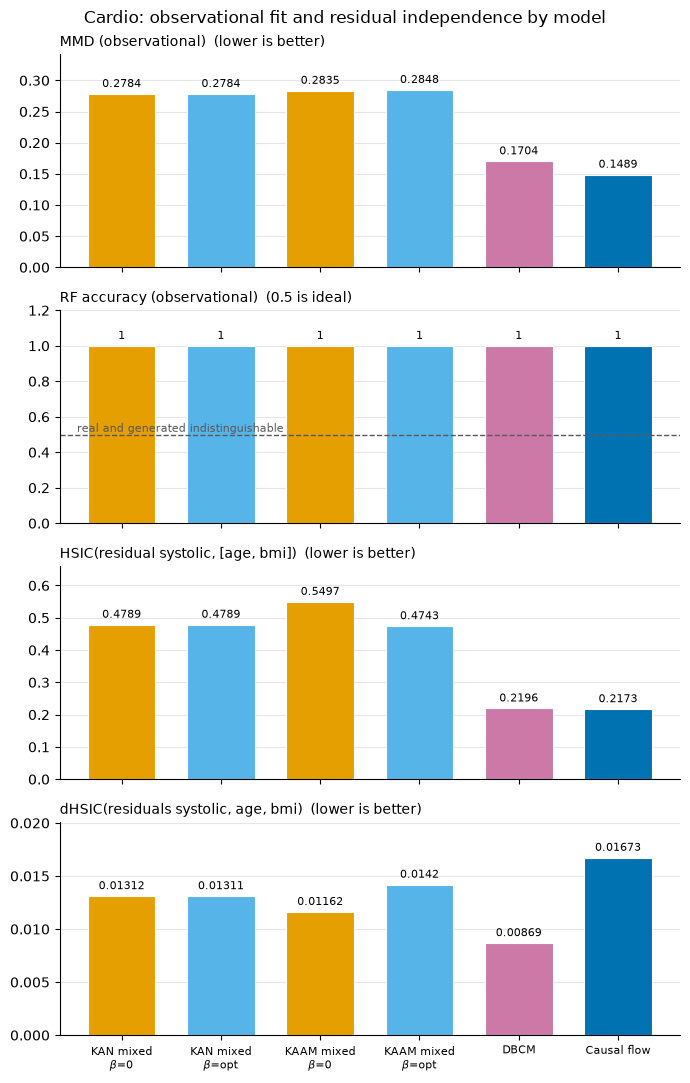


Figure written to C:\Users\aarna\Desktop\clau\TFM Claudia\kacgm-hsic\outputs\cardio\figures


In [50]:
# ============================================================== Metric comparison bar chart
# One vertical subplot per metric, one bar per model. MAE is excluded: it is only defined for
# the KAN/KAAM family, so dbcm/flow have no comparable value (see evaluate_cardio_observational).
# Each bar is the single stored value of that metric, not an average over repetitions.

# Falls back to the stored results file so the cell also works on a fresh kernel.
if 'results' in dir() and results:
    plot_results = results
else:
    with open(os.path.join(data_dir, 'cardio_results_all.pkl'), 'rb') as f:
        plot_results = pickle.load(f)

# (results key, display label, bar colour) in the order the bars are drawn.
BAR_MODELS = [
    ('kan_mixed_beta0',  'KAN mixed\n$\\beta$=0',    '#E69F00'),
    ('kan_mixed',        'KAN mixed\n$\\beta$=opt',  '#56B4E9'),
    ('kaam_mixed_beta0', 'KAAM mixed\n$\\beta$=0',   '#E69F00'),
    ('kaam_mixed',       'KAAM mixed\n$\\beta$=opt', '#56B4E9'),
    ('dbcm',             'DBCM',                     '#CC79A7'),
    ('flow',             'Causal flow',              '#0072B2'),
]

BAR_METRICS = [
    ('mmd_obs_avg',    'MMD (observational)',                 'lower is better'),
    ('rf_acc_obs_avg', 'RF accuracy (observational)',          '0.5 is ideal'),
    ('hsic',           'HSIC(residual systolic, [age, bmi])',  'lower is better'),
    ('dhsic',          'dHSIC(residuals systolic, age, bmi)',  'lower is better'),
]

missing = [key for key, _, _ in BAR_MODELS if key not in plot_results]
if missing:
    print(f'WARNING: no results for {missing} -- run the corresponding cells first.')

bar_keys = [key for key, _, _ in BAR_MODELS if key in plot_results]
bar_labels = [label for key, label, _ in BAR_MODELS if key in plot_results]
bar_colors = [color for key, _, color in BAR_MODELS if key in plot_results]
positions = np.arange(len(bar_keys))

bar_table = pd.DataFrame(
    {metric: [plot_results[key].get(metric, np.nan) for key in bar_keys] for metric, _, _ in BAR_METRICS},
    index=bar_keys,
)
print(tabulate(bar_table.round(4), headers='keys', tablefmt='github'))

fig, axs = plt.subplots(len(BAR_METRICS), 1, figsize=(7, 11), sharex=True)

for ax, (metric, title, direction) in zip(axs, BAR_METRICS):
    values = bar_table[metric].to_numpy(dtype=float)
    # White edges give the separation between adjacent bars.
    bars = ax.bar(positions, values, width=0.68, color=bar_colors, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, labels=[f'{v:.4g}' for v in values], padding=3, fontsize=8)

    if metric == 'rf_acc_obs_avg':
        ax.axhline(0.5, color='0.35', ls='--', lw=1)
        ax.text(-0.45, 0.5, 'real and generated indistinguishable', va='bottom', ha='left',
                fontsize=8, color='0.35')

    ax.set_title(f'{title}  ({direction})', fontsize=10, loc='left')
    # Bars must start at zero; the headroom keeps the value labels off the frame.
    ax.set_ylim(0, float(np.nanmax(values)) * 1.20 if np.isfinite(values).any() else 1)
    ax.grid(axis='y', color='0.9', lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

axs[-1].set_xticks(positions)
axs[-1].set_xticklabels(bar_labels, fontsize=8)
fig.suptitle('Cardio: observational fit and residual independence by model', fontsize=12)
fig.tight_layout()

figures_dir = str(paths.figures)
fig.savefig(os.path.join(figures_dir, 'cardio_metrics_bars.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'cardio_metrics_bars.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f'\nFigure written to {figures_dir}')